# Study Area — Oued Sikkak Watershed

**AI for Hydrogeologists** — companion notebook (shared across Chapters 4, 5, 7)

This notebook builds a single reference map of the Sikkak watershed showing
the basin boundary, stream network, and every sampling network used across
the book: Hennaya piezometers (Ch. 4), hydrochemistry points (Ch. 5), and
the spring/well inventory (Ch. 7).

**Data caveat, stated explicitly.** The shapefiles were supplied as `.shp`
geometry only, without their usual `.shx` index and `.dbf` attribute table
companions, and without a `.prj` projection file. Geometry could still be
read (pyshp can reconstruct the shape index from the `.shp` file alone in
most cases), but no attribute table exists for either layer, and the
coordinate reference system was confirmed only by comparing coordinate
ranges against the other datasets in this project (UTM Zone 30N, EPSG:32630
— consistent with all other chapters).

**Basin area discrepancy, stated explicitly.** The digitized basin boundary
encloses approximately 458 km2, roughly double the 218 km2 figure from
Bouanani et al. (2013) used for the water-balance unit conversions in
Chapter 7. This most likely reflects two different delineation outlets (the
full basin vs. a gauged sub-basin upstream of a specific hydrometric
station) rather than a digitizing error, but this has not been confirmed
against the original source. Both figures are reported rather than
silently reconciled.

In [1]:
!pip install pyshp shapely contextily -q

import shapefile
from shapely.geometry import shape
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import urllib.request, io

BASE = "https://raw.githubusercontent.com/Dr-LAOUFIAbdessalam/ai-hydrogeologists/main/"


## Load geometry and point datasets

In [2]:
def load_shp_geometry_only(url):
    data = urllib.request.urlopen(url).read()
    sf = shapefile.Reader(shp=io.BytesIO(data))
    return sf

basin_sf = load_shp_geometry_only(BASE + "ch07_recharge/study_area/data/raw/bassin_de_sikkak.shp")
basin_geom = shape(basin_sf.shape(0).__geo_interface__)
basin_area_km2 = basin_geom.area / 1e6

streams_sf = load_shp_geometry_only(BASE + "ch07_recharge/study_area/data/raw/cours_eaux.shp")
stream_geoms = [shape(s.__geo_interface__) for s in streams_sf.shapes()]

print(f"Digitized basin area: {basin_area_km2:.1f} km2")
print("Literature value (Bouanani et al. 2013, used in Chapter 7): 218 km2")
print(f"Number of stream segments: {len(stream_geoms)}")

water_points = pd.read_csv(BASE + "ch07_recharge/data/raw/points_d_eau_sikkak.csv")
water_points["type"] = water_points["Source"].apply(lambda s: "Spring" if s.startswith("Ain") else "Well (extraction)")
heads = pd.read_csv(BASE + "ch04_groundwater_level/data/raw/heads_clean.csv")
hydrochem = pd.read_csv(BASE + "ch05_quality_contamination/data/raw/hennaya_hydrochem_tidy.csv")


Digitized basin area: 457.9 km2
Literature value (Bouanani et al. 2013, used in Chapter 7): 218 km2
Number of stream segments: 603


## Map with satellite basemap

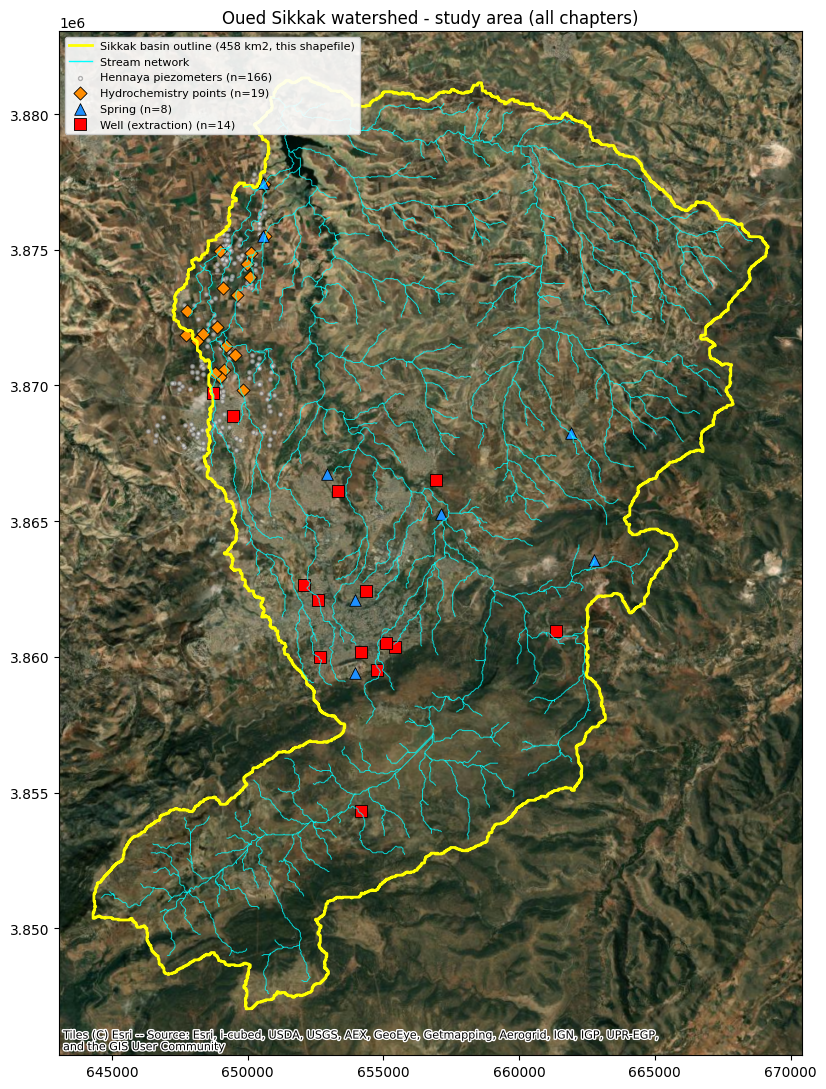

In [3]:
import contextily as cx

fig, ax = plt.subplots(figsize=(11, 11))

if basin_geom.geom_type == "Polygon":
    xs, ys = basin_geom.exterior.xy
    ax.plot(xs, ys, color="yellow", linewidth=2,
            label=f"Sikkak basin outline ({basin_area_km2:.0f} km2, this shapefile)")
else:
    for part in basin_geom.geoms:
        xs, ys = part.exterior.xy
        ax.plot(xs, ys, color="yellow", linewidth=2)

for geom in stream_geoms:
    parts = [geom] if geom.geom_type == "LineString" else geom.geoms
    for part in parts:
        xs, ys = part.xy
        ax.plot(xs, ys, color="cyan", linewidth=0.7, alpha=0.8)
ax.plot([], [], color="cyan", linewidth=1, label="Stream network")

ax.scatter(heads["x"], heads["y"], c="white", s=8, alpha=0.6, edgecolor="grey",
           label=f"Hennaya piezometers (n={len(heads)})")
hc_unique = hydrochem.drop_duplicates("point")
ax.scatter(hc_unique["x"], hc_unique["y"], c="darkorange", s=45, marker="D",
           edgecolor="k", linewidth=0.6, label=f"Hydrochemistry points (n={len(hc_unique)})")
for t, color, marker in [("Spring", "dodgerblue", "^"), ("Well (extraction)", "red", "s")]:
    sub = water_points[water_points.type == t]
    ax.scatter(sub["x"], sub["y"], c=color, s=70, marker=marker,
               edgecolor="k", linewidth=0.6, label=f"{t} (n={len(sub)})")

ax.set_aspect("equal")
ax.set_title("Oued Sikkak watershed - study area (all chapters)")
ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
cx.add_basemap(ax, crs="EPSG:32630", source=cx.providers.Esri.WorldImagery)
plt.tight_layout()
plt.show()
